# Prueba de progreso 3
## 1. Introducción
El objetivo es predecir el nivel de daño sufrido por edificios tras el terremoto de Nepal de 2015.

La variable objetivo contiene un rango de 3 números estrictamente enteros:

- damage_grade = 1 → daño bajo
- damage_grade = 2 → daño medio
- damage_grade = 3 → daño severo

Se trata de un problema de clasificación multiclase ordinal parecido al estudiado durante la prueba de progreso 1.
## 2. Carga de datos
Los datos se cargan como CSV. En contreto los datos vienen de "test_values", "train_labels" y "train_values" proporcionados por DrivenData para la competición de aprendizaje.
El conjunto de entrenamiento contiene las características de los edificios y el nivel de daño sufrido tras el terremoto.

El conjunto de prueba contiene únicamente las características, ya que el objetivo será predecir la variable `damage_grade`.


In [17]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Cargar datasets
X_train = pd.read_csv("train_values.csv", index_col="building_id")
y_train = pd.read_csv("train_labels.csv", index_col="building_id")

X_test = pd.read_csv("test_values.csv", index_col="building_id")

## 3. Revisión de los datos
Se han observado las fuenetes de datosd al abrirlas con notepad++ , también se han revisado el formato y estructura de los datos con la función "head" e "info" de los dataframes de pandas.
También se han revisado los datos núlos y Tipos de datos con "isnull" y _"dtypes". Además con "describe" podemos obtener medias aritméticas, máximos y mínimos que serán realemnte útiles para comprender los datos Y percentiles para entender si hay valores extremos o atípicos.
Se han combinado los valores y las etiquetas de entrenamiento para reducir el tamaño del problema.

In [5]:
df = X_train.copy()
df["damage_grade"] = y_train["damage_grade"]

# Mostrar dimensiones
print("Train:", X_train.shape)
print("Labels:", y_train.shape)
print("Test:", X_test.shape)

df.head()
df.info()

# Verificar valores nulos
print("Valores nulos en train:")
print(X_train.isnull().sum())
print("\nValores nulos en test:")
print(X_test.isnull().sum())

# Verificar tipos de datos
print("Tipos de datos en train:")
print(X_train.dtypes)
print("\nTipos de datos en test:")
print(X_test.dtypes)

# Estadísticas descriptivas
print("Estadísticas descriptivas de train:")
print(X_train.describe())
print("\nEstadísticas descriptivas de test:")
print(X_test.describe())

Train: (260601, 38)
Labels: (260601, 1)
Test: (86868, 38)
<class 'pandas.DataFrame'>
Index: 260601 entries, 802906 to 747594
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   geo_level_1_id                          260601 non-null  int64
 1   geo_level_2_id                          260601 non-null  int64
 2   geo_level_3_id                          260601 non-null  int64
 3   count_floors_pre_eq                     260601 non-null  int64
 4   age                                     260601 non-null  int64
 5   area_percentage                         260601 non-null  int64
 6   height_percentage                       260601 non-null  int64
 7   land_surface_condition                  260601 non-null  str  
 8   foundation_type                         260601 non-null  str  
 9   roof_type                               260601 non-null  str  
 10  ground_floor_type    

Se ha observado que el dataset tiene 260000 entradas con 39 variables de las cuales 31 son numéricas y 8 son categóricas. No hay valores nulos. Se ha observado algún valor atípico como un edificio con 995 años siendo percentil 75 los 30 años y edificios con 9 plantas siendo el percentil 75 2 plantas (y la media ligeramente por encima de 2). Son valores que se tendrán en cuenta aunque no afecten al resultado de la predicción.

Se ha observado la distribución de la variable objetivo mediante un "plot" de los valores de entenamiento

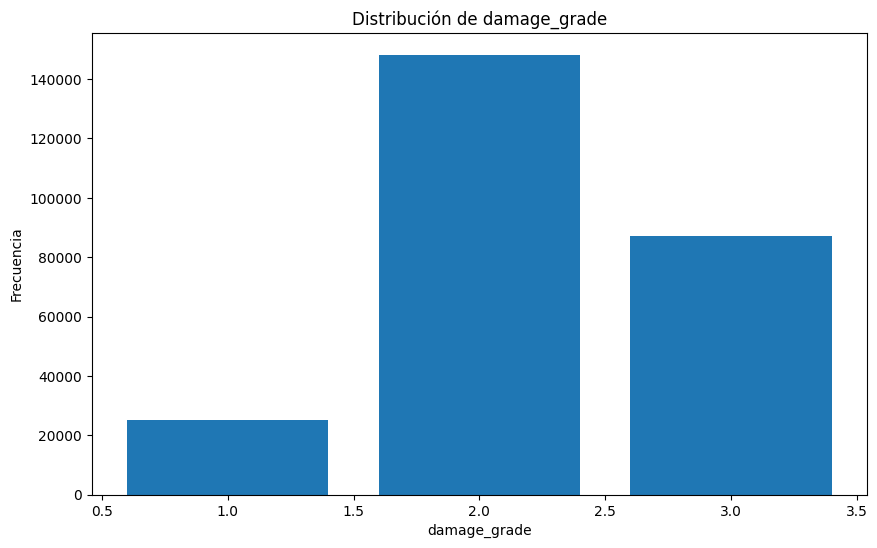

In [6]:
# Visualizar la distribución de la variable objetivo
plt.figure(figsize=(10, 6))
plt.bar(y_train["damage_grade"].value_counts().sort_index().index, y_train["damage_grade"].value_counts().sort_index().values)
plt.title("Distribución de damage_grade")
plt.xlabel("damage_grade")
plt.ylabel("Frecuencia")
plt.show()

Se han elegido las variables mas prometedoras par hacer la predicción, se han observado si hay relación aparente entre las variables y la variable objetivo (el tiempo de ejecución del siguiente código puede ser elevado):

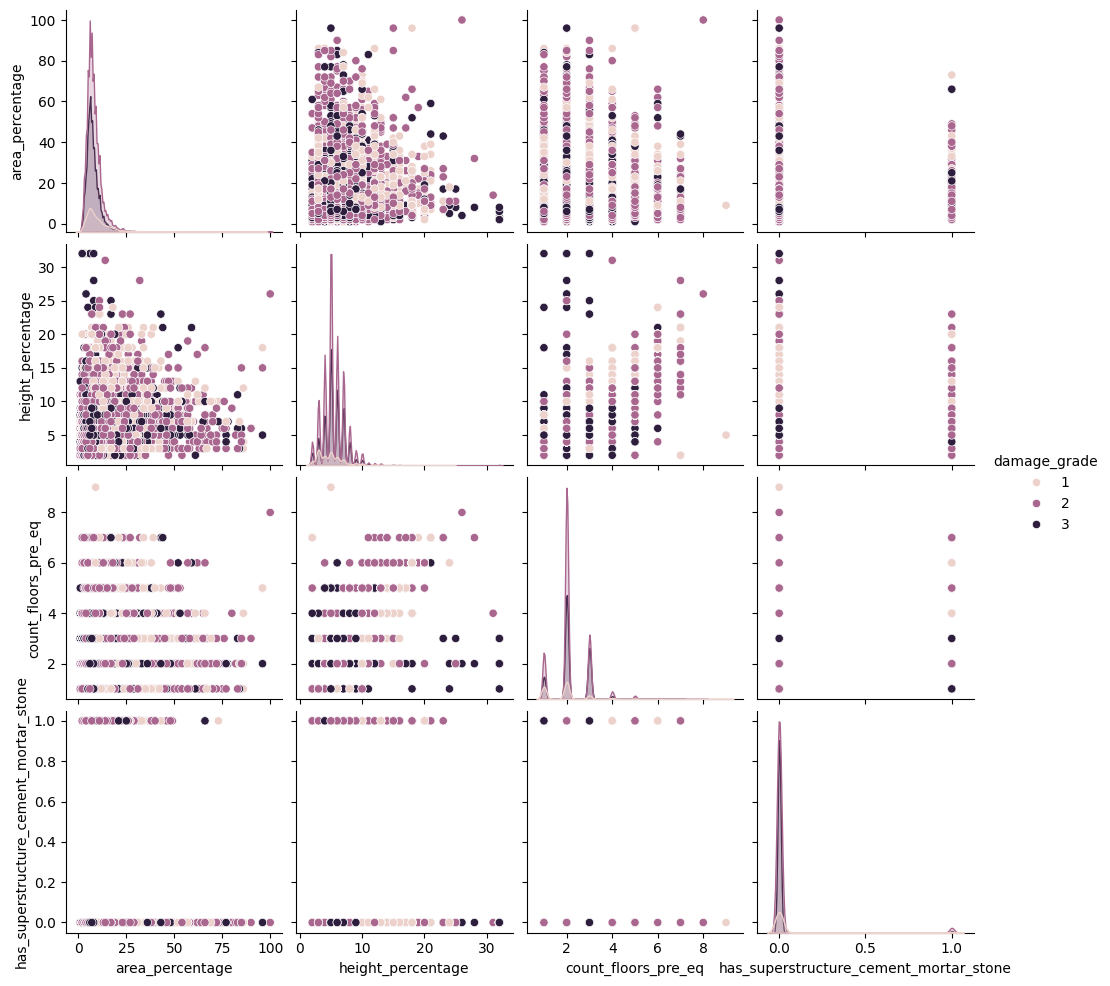

In [9]:
# preselección de características basada en el análisis exploratorio
selected_features = [
    "foundation_type",
    "area_percentage",
    "height_percentage",
    "count_floors_pre_eq",
    "land_surface_condition",
    "has_superstructure_cement_mortar_stone",
]



train_values_subset = X_train[selected_features]

sns.pairplot(train_values_subset.join(y_train["damage_grade"]), hue="damage_grade")
plt.show()

### 3.1 Relación observada con (`damage_grade`)
No se observan separaciones perfectamente definidas entre clases, lo que sugiere que el problema no puede resolverse mediante reglas simples o lineales.
Sin embargo, sí aparecen ciertos patrones:
- Los edificios con más plantas parecen concentrar una mayor proporción de daños elevados.
- Las estructuras con determinadas características constructivas muestran comportamientos distintos frente al daño por terremoto.
- Las variables estructurales probablemente interactúan entre sí.

## 4. Preprocesamiento
Sobre el subset elegido se ha codificado las variables categóricas con:

In [10]:
# preprocesamiento de datos: codificación de variables categóricas
train_values_subset = pd.get_dummies(train_values_subset)

## 5. Entrenamiento del modelo
Inicialmente se ha realizado el entrenamiento del modelo con Random Forest Classifier debido a que manejan correctamente relaciones no lineales entre variables, son robustos frente al ruido y los outliers y Pueden trabajar adecuadamente con variables binarias y categóricas codificadas.
Posteriormente se ha utilizado XGBoost para uan estimación mas concreta e intentar obtener un mejor resultado en la predicción.
La evaluación se realizó utilizando la métrica **Micro F1-score**, que es la metrica propuesta por la guia de la página y que seguramente sea la utilizada para obtener el score en el leaderboard.

### 5.1 Random Forest
El objetivo de esta fase inicial fue comprobar rápidamente el comportamiento del modelo antes de entrenarlo utilizando el conjunto completo de características.

El conjunto de datos se dividió en:

- 80 % para entrenamiento
- 20 % para validación

In [22]:
# Random Forest subset
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(train_values_subset, y_train["damage_grade"], test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_val_rf)
# Evaluar el modelo con micro F1-score
f1_rf = f1_score(y_val_rf, y_pred_rf, average="micro")
print(f"Random Forest Micro F1-score: {f1_rf:.4f}")

Random Forest Micro F1-score: 0.7020


Como se puede observar se obtuvo un micro F1-score de 0.5765 que es una aproximación decente pero que indica que faltan valores necesarios para la predicción. Para ello voy a repetir Random Forest con todas las características:

In [14]:
# Random Forest todas las características
train_values_encoded = pd.get_dummies(X_train)
test_values_encoded = pd.get_dummies(X_test)

X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    train_values_encoded,
    y_train["damage_grade"],
    test_size=0.2,
    stratify=y_train["damage_grade"],
    random_state=42
)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_val_rf)
f1_rf = f1_score(y_val_rf, y_pred_rf, average="micro")
print(f"Random Forest Micro F1-score: {f1_rf:.4f}")

Random Forest Micro F1-score: 0.7160


Ahora el micro F1-score es mas alto indicando que hay variables importantes no tenidas en cuenta como son las variables geológicas. Con lo cual se ha repetido una ultima vez con las siguientes variables y ajustando un poco los parámetros del random forest classifier para aumentar el numero de stimadores y hojas minimas por rama:

In [19]:
# preselección de características basada en el análisis exploratorio
selected_features = [
    "foundation_type",
    "area_percentage",
    "height_percentage",
    "count_floors_pre_eq",
    "land_surface_condition",
    "has_superstructure_cement_mortar_stone",
    "has_superstructure_mud_mortar_stone",
    "geo_level_1_id",
    "geo_level_2_id",
    "geo_level_3_id"
]


train_values_subset = X_train[selected_features]

# preprocesamiento de datos: codificación de variables categóricas
train_values_subset = pd.get_dummies(train_values_subset)


# Random Forest subset
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(train_values_subset, y_train["damage_grade"], test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_val_rf)
f1_rf = f1_score(y_val_rf, y_pred_rf, average="micro")
print(f"Random Forest Micro F1-score: {f1_rf:.4f}")

Random Forest Micro F1-score: 0.7214


### 5.2 XGBoost
Tras obtener un buen rendimiento inicial con Random Forest como modelo base, se decidió implementar XGBoost como un segundo enfoque debido a su capacidad para mejorar el rendimiento en problemas de clasificación mediante técnicas de boosting aprendidas en el trabajo teórico. A diferencia de Random Forest, que combina múltiples árboles de forma independiente mediante bagging, XGBoost construye los árboles de manera secuencial, corrigiendo los errores de los modelos anteriores, lo que suele permitir capturar relaciones más complejas en los datos.

Además, XGBoost incorpora mecanismos de regularización que ayudan a reducir el sobreajuste, algo especialmente relevante en este conjunto de datos con muchas variables categóricas y posibles interacciones no lineales. Por este motivo, tras el baseline inicial con Random Forest, se utilizó XGBoost como un modelo más potente y ajustado, obteniendo una mejora en el rendimiento con un F1-score sobre random forest.

In [20]:
# XGBoost 

y_train_aux = y_train.copy()
# XGBoost requiere clases 0,1,2 en lugar de 1,2,3 asi que dependemos de una transformación simple restando 1 a las etiquetas y guardandolo como auxiliar
y_train_aux["damage_grade"] = y_train_aux["damage_grade"] - 1
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split( train_values_subset, y_train_aux["damage_grade"], test_size=0.2, random_state=42 )

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(X_train_xgb, y_train_xgb)
y_pred_xgb = xgb_model.predict(X_val_xgb)
f1_xgb = f1_score(y_val_xgb, y_pred_xgb, average="micro")
print(f"XGBoost Micro F1-score: {f1_xgb:.4f}")


XGBoost Micro F1-score: 0.7349


## 6. Generación de predicciones y archivo de *submission*

En esta fase del proceso se prepara el conjunto de datos de test para generar las predicciones finales que serán enviadas a la plataforma DrivenData. En primer lugar, se seleccionan las mismas variables utilizadas durante el entrenamiento del modelo (`selected_features`) con el objetivo de garantizar la coherencia entre los datos de entrenamiento y de prueba.

Posteriormente, se aplica un proceso de codificación de variables categóricas mediante "get_dummies()" como se hizo con las pruebas, transformando las variables no numéricas en un formato adecuado para el modelo de aprendizaje automático.

A continuación, se entrena el modelo final utilizando todos los datos disponibles del conjunto de entrenamiento, incluyendo tanto las características como las etiquetas. Este reentrenamiento completo se realiza para maximizar la capacidad de generalización del modelo antes de realizar las predicciones finales.

Una vez entrenado el modelo, se generan las predicciones sobre el conjunto de test. Dado que durante el entrenamiento las clases fueron reescaladas (0, 1, 2) para adaptarse a los requisitos de XGBoost, se realiza una transformación inversa sumando 1 a las predicciones para recuperar el formato original de las etiquetas (1, 2, 3).

Finalmente, se construye un archivo de *submission* en formato `csv`, que contiene el identificador de cada edificio (`building_id`) junto con la predicción de su nivel de daño (`damage_grade`). Este archivo es el que se envía a la competición para su evaluación en el *leaderboard*.

In [21]:
# Preparar test
test_values_subset = X_test[selected_features]
# preprocesamiento de datos: codificación de variables categóricas
test_values_subset = pd.get_dummies(test_values_subset)
# Entrenar modelo final con todos los datos
xgb_model.fit(train_values_subset, y_train_aux["damage_grade"])

# Predecir test
test_preds = xgb_model.predict(test_values_subset)
test_preds = test_preds + 1  # volver a 1,2,3

# Crear submission
submission = pd.DataFrame({
    "building_id": X_test.index,
    "damage_grade": test_preds
})

submission.to_csv("submission.csv", index=False)

## 7. Subida a DrivenData
Se ha subido el archivo *submission* generado en el anterior apartado y ha proporcionado un score ligeramente superior al observado en local siendo este 0.7355 y estando en posición 1335 a fecha de 18/05/2026 
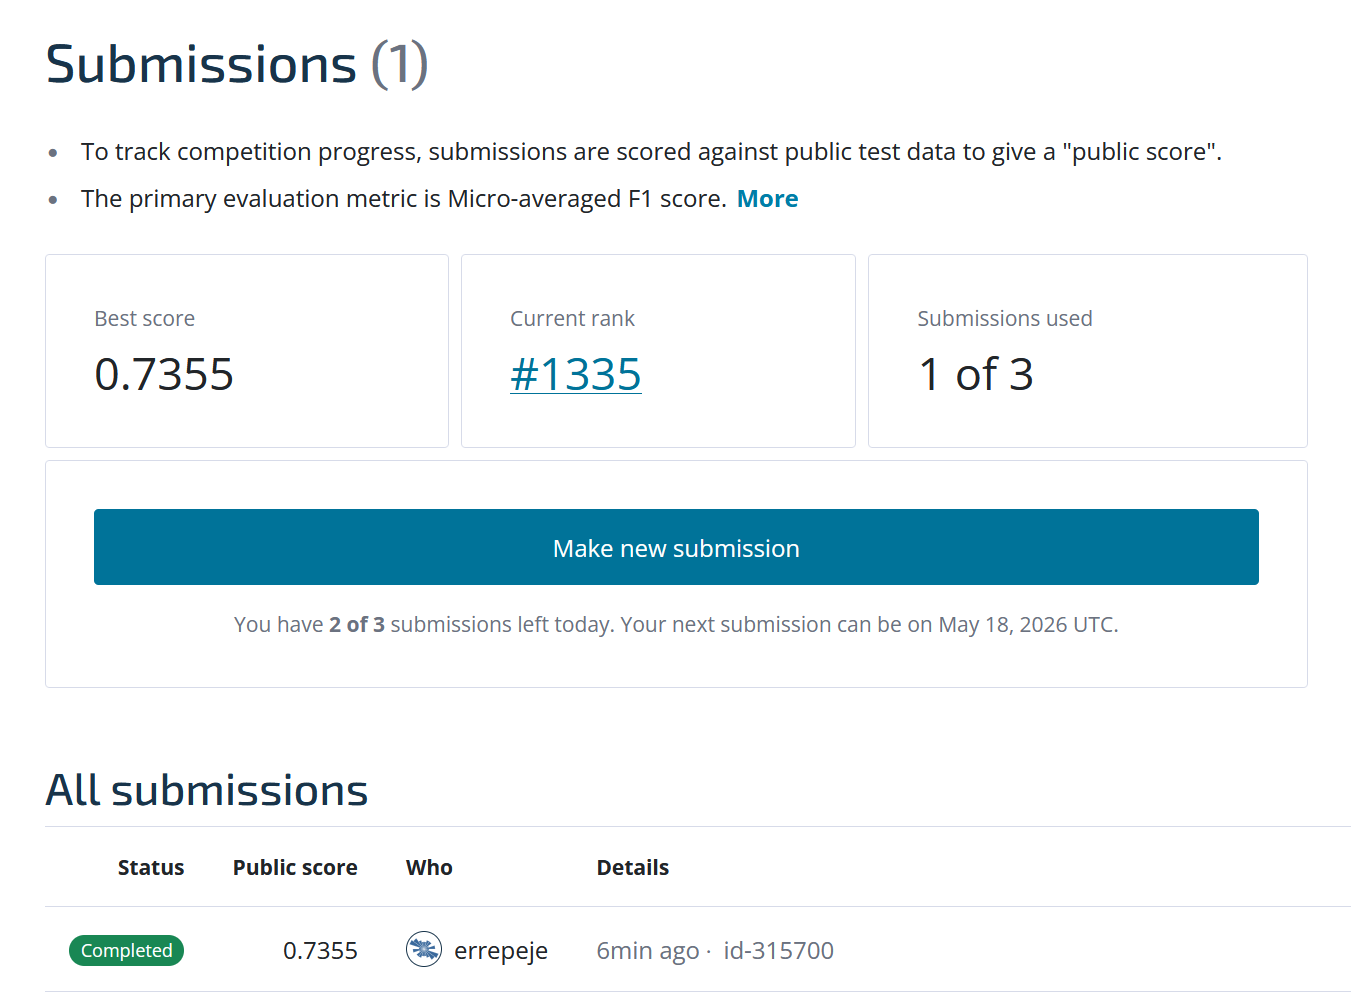